<a href="https://colab.research.google.com/github/SibteAliQ04/Library-Circulation/blob/main/Copy_of_Untitled17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Load batting data
batting = pd.read_csv('Batting.csv')

In [3]:
active_players = batting[batting['AB'] > 0]
active_players.describe()

,yearID,stint,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
count,106470.000000,106470.000000,106470.000000,106470.000000,106470.000000,106470.000000,106470.000000,106470.000000,106470.000000,105715.000000,103927.000000,74495.000000,106470.000000,97871.000000,60574.000000,103657.000000,100421.000000,60441.000000,71564.000000
mean,1961.015610,1.087217,52.752775,156.280783,20.881253,40.784024,6.967597,1.394440,3.247018,18.996500,3.299662,1.429358,14.402808,24.664722,1.303942,1.230385,2.477330,1.333532,3.603250
std,40.618563,0.309582,47.736202,183.445456,28.332393,52.344675,9.771709,2.643194,6.676413,26.617856,7.804549,2.884041,20.843173,30.679386,2.940012,2.424457,4.226708,2.095587,4.940732
min,1871.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1928.000000,1.000000,13.000000,14.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1964.000000,1.000000,35.000000,68.000000,7.000000,14.000000,2.000000,0.000000,0.000000,6.000000,0.000000,0.000000,4.000000,13.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,1998.000000,1.000000,85.000000,255.000000,32.000000,65.000000,11.000000,2.000000,3.000000,28.000000,3.000000,2.000000,21.000000,34.000000,1.000000,1.000000,3.000000,2.000000,6.000000
max,2025.000000,6.000000,165.000000,716.000000,198.000000,262.000000,67.000000,36.000000,73.000000,191.000000,138.000000,42.000000,232.000000,223.000000,120.000000,51.000000,67.000000,19.000000,36.000000


In [5]:
batting.groupby('playerID')['HR'].sum().sort_values(ascending=False)

,HR
playerID,
bondsba01,762
aaronha01,755
ruthba01,714
pujolal01,703
rodrial01,696
...,...
abadijo01,0
abadfe01,0
zmiched01,0


In [6]:
# Filtering for only Babe Ruth's rows
babe_ruth = batting[batting['playerID'] == 'ruthba01']

# Finding the starting and ending years
start_year = babe_ruth['yearID'].min()
end_year = babe_ruth['yearID'].max()

In [7]:
# Filtering for players that played the same years as Babe
ruth_years = batting[(batting['yearID'] >= start_year) & (batting['yearID'] <= end_year)]

# Finding the home run leaders during that time
ruth_years.groupby('playerID')['HR'].sum().sort_values(ascending=False)

,HR
playerID,
ruthba01,714
gehrilo01,378
foxxji01,302
hornsro01,300
simmoal01,256
...,...
zapusjo01,0
zahnipa01,0
zabelzi01,0


In [8]:
total_hr_by_year = batting.groupby('yearID')['HR'].sum()

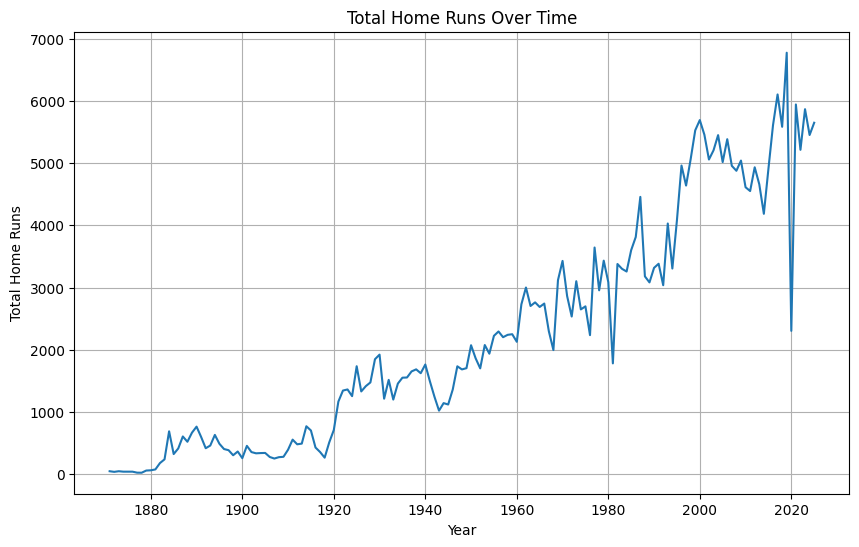

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(total_hr_by_year.index, total_hr_by_year.values)

# Adding labels
plt.title('Total Home Runs Over Time')
plt.xlabel('Year')
plt.ylabel('Total Home Runs')

plt.grid(True)
plt.show()

In [10]:
team_hr_per_year = (
  batting
  .groupby(['yearID', 'teamID'])['HR']
  .sum()
  .reset_index()
)

In [11]:
rockies_hr = (
  team_hr_per_year
  [team_hr_per_year['teamID'] == 'COL']
  .set_index('yearID')['HR']
)

In [12]:
league_avg_hr = (
  team_hr_per_year
  .groupby('yearID')['HR']
  .mean()
)

league_avg_hr = league_avg_hr[league_avg_hr.index >= 1993]

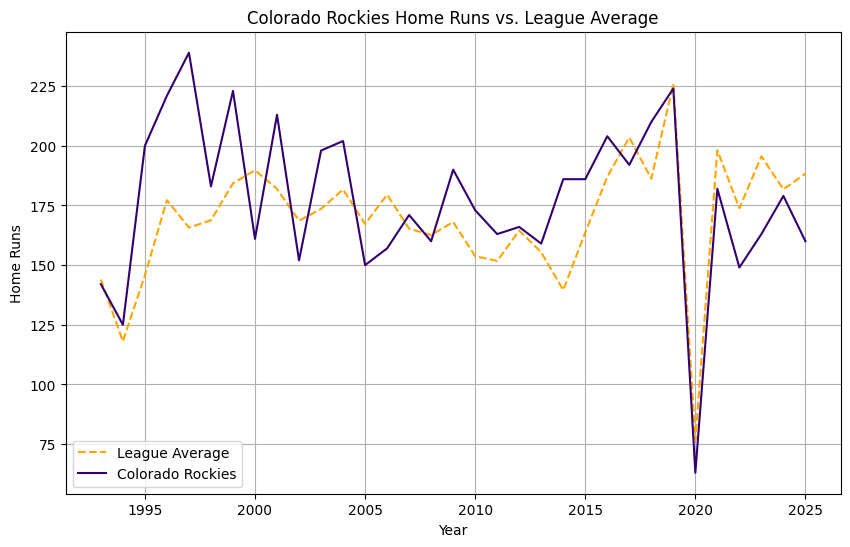

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(league_avg_hr.index,
  league_avg_hr.values,
  label='League Average',
  color='orange',
  linestyle='--'
)

plt.plot(
  rockies_hr.index,
  rockies_hr.values,
  label='Colorado Rockies',
  color='#33006F'
)

plt.title('Colorado Rockies Home Runs vs. League Average')
plt.xlabel('Year')
plt.ylabel('Home Runs')
plt.legend()

plt.grid(True)
plt.show()

In [14]:
# Fill missing values to avoid NaN issues
batting[['BB', 'HBP', 'SF']] = batting[['BB', 'HBP', 'SF']].fillna(0)

# Create OBP column
batting['OBP'] = (
  (batting['H'] + batting['BB'] + batting['HBP']) /
  (batting['AB'] + batting['BB'] + batting['HBP'] + batting['SF'])
)

# If we got NaN due to no plate appearances, then fill with 0
batting['OBP'] = batting['OBP'].fillna(0)

In [16]:
# Load data
salaries = pd.read_csv('Salaries.csv')

# Merge salary data into batting data
batting_with_salary = batting.merge(
  salaries,
  on=['playerID', 'yearID', 'teamID'],
  how='left'
)

batting_with_salary.head()

,playerID,yearID,stint,teamID,lgID_x,G,AB,R,H,2B,...,BB,SO,IBB,HBP,SH,SF,GIDP,OBP,lgID_y,salary
0,aardsda01,2004,1,SFN,NL,11,0,0,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NL,300000.0
1,aardsda01,2006,1,CHN,NL,45,2,0,0,0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN
2,aardsda01,2007,1,CHA,AL,25,0,0,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AL,387500.0
3,aardsda01,2008,1,BOS,AL,47,1,0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,AL,403250.0
4,aardsda01,2009,1,SEA,AL,73,0,0,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AL,419000.0


In [17]:
value_df = batting_with_salary[
  (batting_with_salary['salary'] > 0) &
  (batting_with_salary['OBP'] > 0) &
  (batting_with_salary['AB'] >= 200)
].copy()

In [18]:
# Calculate OBP per dollar
value_df['OBP_per_dollar'] = value_df['OBP'] / value_df['salary']

value_df_sorted = value_df.sort_values(
  by='OBP_per_dollar',
  ascending=False
)

value_df_sorted[[
  'playerID',
  'yearID',
  'teamID',
  'OBP',
  'salary',
  'OBP_per_dollar'
]].head()

,playerID,yearID,teamID,OBP,salary,OBP_per_dollar
63670,krukjo01,1986,SDN,0.403077,60000.0,0.000007
104358,seitzke01,1987,KCA,0.399171,62500.0,0.000006
127820,youngge02,1987,HOU,0.379538,62500.0,0.000006
75381,mcgrifr01,1987,TOR,0.376404,62500.0,0.000006
72063,martida01,1987,CHN,0.371869,62500.0,0.000006


In [19]:
value_df_sorted[value_df_sorted['yearID'] == 2010][[
  'playerID',
  'yearID',
  'teamID', 'AB',
  'OBP',
  'salary',
  'OBP_per_dollar'
]].head()

,playerID,yearID,teamID,AB,OBP,salary,OBP_per_dollar
51477,heywaja01,2010,ATL,520,0.393258,400000.0,9.831461e-07
47326,hanigry01,2010,CIN,203,0.404959,415000.0,9.758040e-07
6020,bartoda02,2010,OAK,556,0.393175,410000.0,9.589636e-07
42639,gonzaca01,2010,COL,587,0.375786,406000.0,9.255817e-07
38348,freesda01,2010,SLN,240,0.360902,400000.0,9.022556e-07
